In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.show()


In [2]:
df = pd.read_csv("owid-covid-data.csv")
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-03,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-04,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-05,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-06,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-07,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN


In [3]:
df.shape


(350085, 67)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350085 entries, 0 to 350084
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    350085 non-null  object 
 1   continent                                   333420 non-null  object 
 2   location                                    350085 non-null  object 
 3   date                                        350085 non-null  object 
 4   total_cases                                 312088 non-null  float64
 5   new_cases                                   340457 non-null  float64
 6   new_cases_smoothed                          339198 non-null  float64
 7   total_deaths                                290501 non-null  float64
 8   new_deaths                                  340511 non-null  float64
 9   new_deaths_smoothed                         339281 non-null  float64
 

In [5]:
df.describe()


,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths_per_million,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
count,3.120880e+05,3.404570e+05,3.391980e+05,2.905010e+05,340511.000000,339281.000000,312088.000000,340457.000000,339198.000000,290501.000000,...,200889.000000,132973.000000,239669.000000,322072.000000,263138.000000,3.500850e+05,1.218400e+04,12184.000000,12184.000000,12184.000000
mean,6.683354e+06,9.601634e+03,9.637066e+03,8.602180e+04,85.511055,85.817071,101749.851259,145.163814,145.696924,872.289356,...,32.909483,50.789962,3.097245,73.713631,0.722464,1.284633e+08,5.281637e+04,9.738648,11.345256,1669.025575
std,4.068903e+07,1.102769e+05,9.447784e+04,4.398873e+05,613.687971,559.130004,151265.689121,1163.714678,599.957847,1100.189784,...,13.573767,31.956100,2.548327,7.395220,0.148976,6.607694e+08,1.492195e+05,12.304441,25.181297,1938.556228
min,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.700000,1.188000,0.100000,53.280000,0.394000,4.700000e+01,-3.772610e+04,-44.230000,-95.920000,-2752.924800
25%,8.090000e+03,0.000000e+00,2.860000e-01,1.270000e+02,0.000000,0.000000,2595.577500,0.000000,0.044000,60.606000,...,22.600000,20.859000,1.300000,69.590000,0.602000,4.490020e+05,1.202250e+02,1.400000,-1.600000,72.395046
50%,7.020500e+04,2.000000e+00,2.485700e+01,1.328000e+03,0.000000,0.143000,28307.659000,0.128000,6.517000,377.169000,...,33.100000,49.839000,2.500000,75.050000,0.740000,5.882259e+06,5.885850e+03,8.075000,5.720000,1105.404700
75%,7.409558e+05,2.640000e+02,4.978570e+02,1.192200e+04,3.000000,5.143000,133506.244000,35.466000,82.411000,1365.925000,...,41.300000,82.502000,4.200000,79.460000,0.829000,2.830170e+07,3.742344e+04,15.360000,16.302500,2740.130200
max,7.714071e+08,8.401961e+06,6.402036e+06,6.972139e+06,27939.000000,14822.000000,737554.506000,228872.025000,37241.781000,6511.209000,...,78.100000,100.000000,13.800000,86.750000,0.957000,7.975105e+09,1.289776e+06,76.620000,377.630000,10292.916000


In [6]:
df = df[['location', 'date', 'total_cases', 'total_deaths', 'new_cases']]
df.head()


,location,date,total_cases,total_deaths,new_cases
0,Afghanistan,2020-01-03,NaN,NaN,0.0
1,Afghanistan,2020-01-04,NaN,NaN,0.0
2,Afghanistan,2020-01-05,NaN,NaN,0.0
3,Afghanistan,2020-01-06,NaN,NaN,0.0
4,Afghanistan,2020-01-07,NaN,NaN,0.0


In [8]:
df['date'] = pd.to_datetime(df['date'])


In [9]:
countries = ['India', 'United States', 'Brazil']
df = df[df['location'].isin(countries)]


In [11]:
df = df[(df['date'] >= '2020-01-01') & (df['date'] <= '2020-12-31')]


In [12]:
df.shape


(1092, 5)

In [13]:
df.fillna(0, inplace=True)


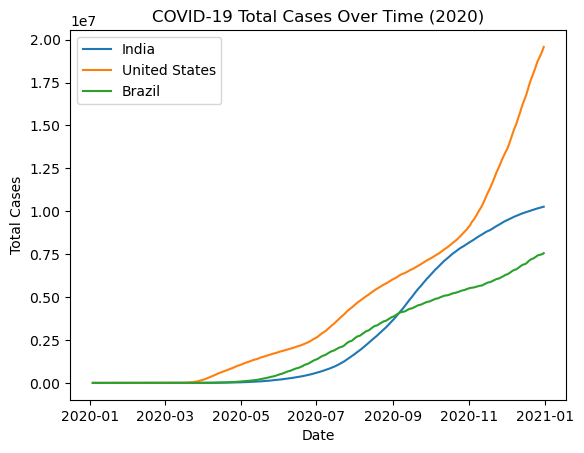

In [14]:
plt.figure()
for country in countries:
    data = df[df['location'] == country]
    plt.plot(data['date'], data['total_cases'], label=country)

plt.xlabel("Date")
plt.ylabel("Total Cases")
plt.title("COVID-19 Total Cases Over Time (2020)")
plt.legend() #box (legend) contains label
plt.show()


## Insights
- The United States shows the highest total cases in 2020.
- All countries experienced sharp increases during peak periods.
- Daily trends indicate multiple COVID-19 waves.


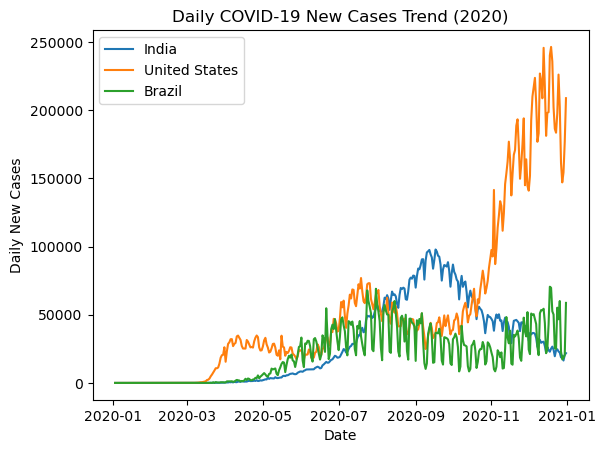

In [15]:
plt.figure()
for country in countries:
    data = df[df['location'] == country]
    plt.plot(data['date'], data['new_cases'], label=country)

plt.xlabel("Date")
plt.ylabel("Daily New Cases")
plt.title("Daily COVID-19 New Cases Trend (2020)")
plt.legend()
plt.show()


In [16]:
country_summary = df.groupby('location')[['total_cases', 'total_deaths']].max()
country_summary


,total_cases,total_deaths
location,,
Brazil,7563551.0,192681.0
India,10266674.0,148738.0
United States,19577585.0,352004.0


In [17]:
df['7_day_avg'] = df.groupby('location')['new_cases'].transform(lambda x: x.rolling(7).mean())


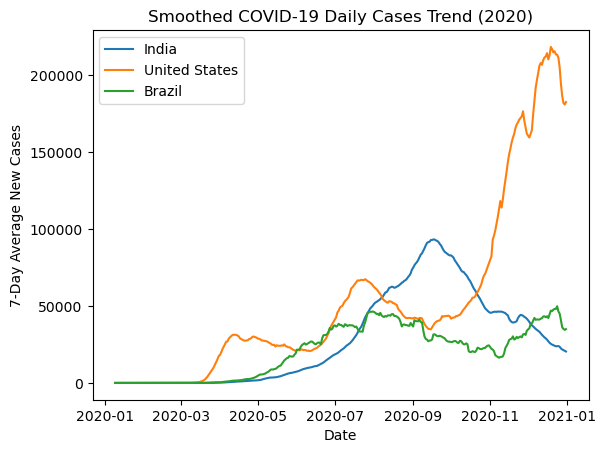

In [18]:
plt.figure()
for country in countries:
    data = df[df['location'] == country]
    plt.plot(data['date'], data['7_day_avg'], label=country)

plt.xlabel("Date")
plt.ylabel("7-Day Average New Cases")
plt.title("Smoothed COVID-19 Daily Cases Trend (2020)")
plt.legend()
plt.show()


## Key Insights
- The United States recorded the highest number of COVID-19 cases in 2020.
- India and Brazil showed similar growth patterns during peak periods.
- Daily new cases fluctuated significantly, indicating multiple waves.
- The 7-day moving average smooths out daily noise and reveals clearer trends.


## Conclusion
This project demonstrates the use of Python for analyzing real-world time-series data.
Key skills applied include data cleaning, filtering, aggregation, and visualization to
derive meaningful insights from COVID-19 data.


***Example for Real time Analysis for Govt***

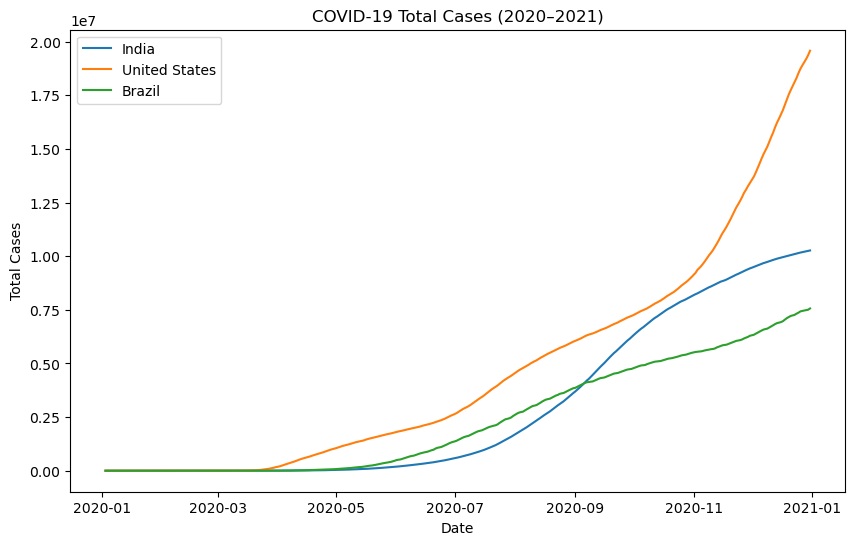

In [20]:
import matplotlib.pyplot as plt

countries = ["India", "United States", "Brazil"]

plt.figure(figsize=(10,6))
for country in countries:
    country_df = df[df['location'] == country]
    plt.plot(country_df['date'], country_df['total_cases'], label=country)

plt.title("COVID-19 Total Cases (2020–2021)")
plt.xlabel("Date")
plt.ylabel("Total Cases")
plt.legend()
plt.show()


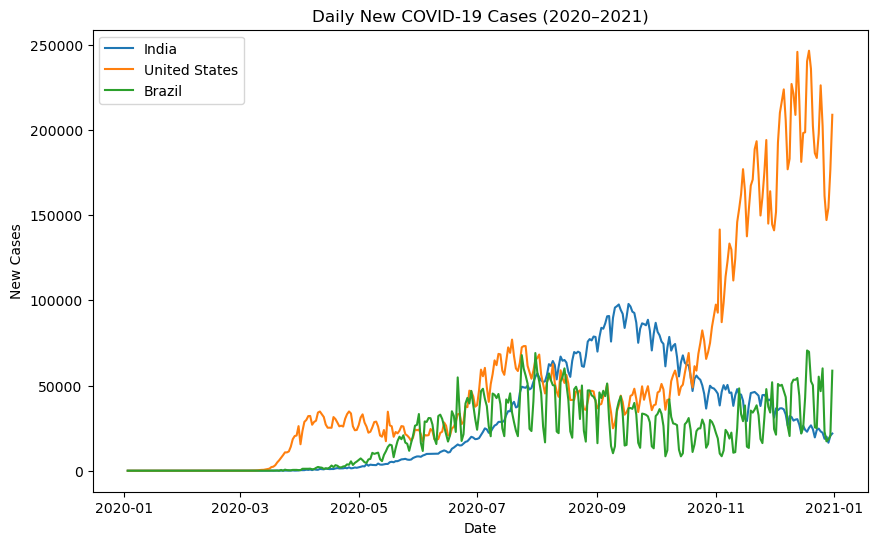

In [21]:
plt.figure(figsize=(10,6))
for country in countries:
    country_df = df[df['location'] == country]
    plt.plot(country_df['date'], country_df['new_cases'], label=country)

plt.title("Daily New COVID-19 Cases (2020–2021)")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.legend()
plt.show()
